In [1]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
file = h5py.File(r"/root/autodl-tmp/dataset/data.h5", "r")
trace_160 = np.array(file["data"]["custom_net)160)1"][:,1]).squeeze()
label_160 = np.array(file["data"]["custom_net)160)1"][:,-1]).squeeze()
print(label_160.shape == trace_160.shape)
trace_331 = np.array(file["data"]["custom_net)331)1"][:,1]).squeeze()
label_331 = np.array(file["data"]["custom_net)331)1"][:,-1]).squeeze()

True


/tmp/ipykernel_1478/187613410.py:36: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


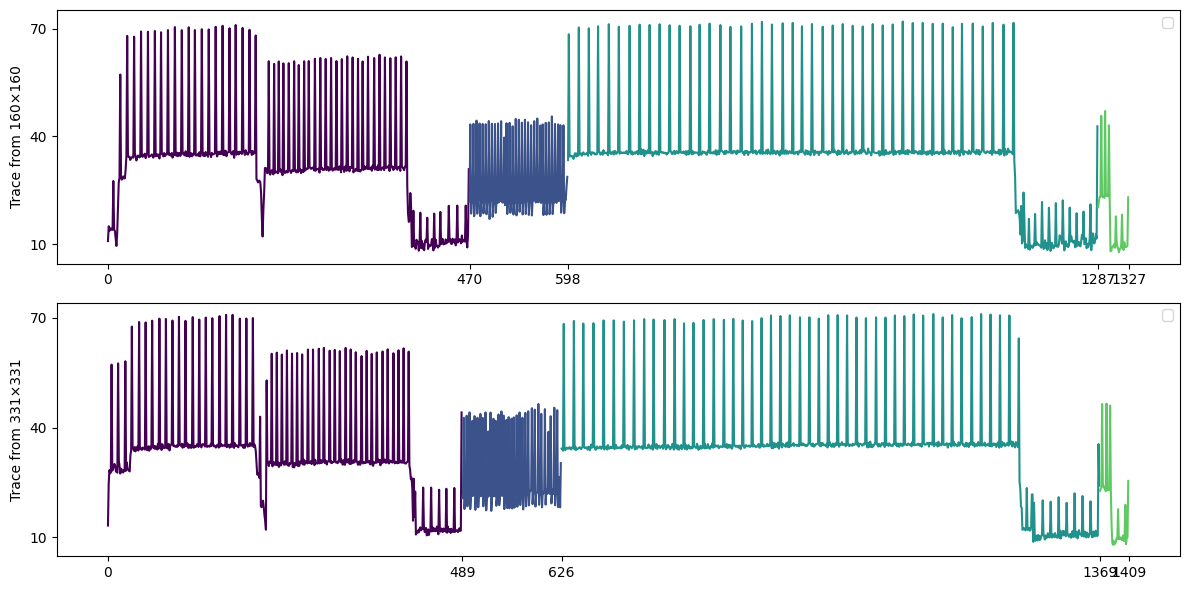

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_colored_trace(signal1, labels1, signal2, labels2, labels_dict=None):
    def plot_trace(ax, signal, labels, with_legend = True):
        unique_labels = np.unique(labels)
        num_labels = len(unique_labels)
        colors = plt.get_cmap('viridis', num_labels)  # 淡色系

        start = 0
        for i in range(1, len(signal)):
            if labels[i] != labels[start]:
                label_id = labels[start]
                label_name = labels_dict.get(label_id, f'Class {label_id}') if labels_dict else f'Class {label_id}'
                existing_labels = ax.get_legend_handles_labels()[1]

                ax.plot(
                    range(start, i),
                    signal[start:i],
                    color=colors(unique_labels.tolist().index(label_id)),
                    # label=(label_name if label_name not in existing_labels else "") if with_legend else None
                )
                start = i

        # 画最后一段
        label_id = labels[start]
        label_name = labels_dict.get(label_id, f'Class {label_id}') if labels_dict else f'Class {label_id}'
        existing_labels = ax.get_legend_handles_labels()[1]
        ax.plot(
            range(start, len(signal)),
            signal[start:],
            color=colors(unique_labels.tolist().index(label_id)),
            # label=(label_name if label_name not in existing_labels else "") if with_legend else None
        )

        # ax.legend()

    # 创建上下两个子图
    fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=False)

    xticks1 = file["position"]["custom_net)160)1"][:,0]
    xticks2 = file["position"]["custom_net)331)1"][:,0]

    plot_trace(axes[0], signal1, labels1)
    axes[0].set_ylabel("Trace from 160×160")
    axes[0].set_yticks([10, 40, 70])
    axes[0].set_xticks(xticks1)


    plot_trace(axes[1], signal2, labels2, with_legend=False)
    axes[1].set_ylabel("Trace from 331×331")
    axes[1].set_yticks([10, 40, 70])
    axes[1].set_xticks(xticks2)

    plt.tight_layout()
    plt.savefig("./plot/whole_trace_compare.eps", format="eps")

    plt.show()


labels_name = {'conv2d': 0, 'batch_norm': 1, 'relu_': 2, 'max_pool2d': 3, 'adaptive_avg_pool2d': 4, 'linear': 5, 'add_': 6, '_': 7}
labels_name = {v: k for k, v in labels_name.items()}
plot_colored_trace(trace_160, label_160, trace_331, label_331, labels_name)

两条来自PP0域，从同一个模型上收集的能量迹，它们的输入尺寸分别为160×160，331×331，不同的颜色标记不同的层类型

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


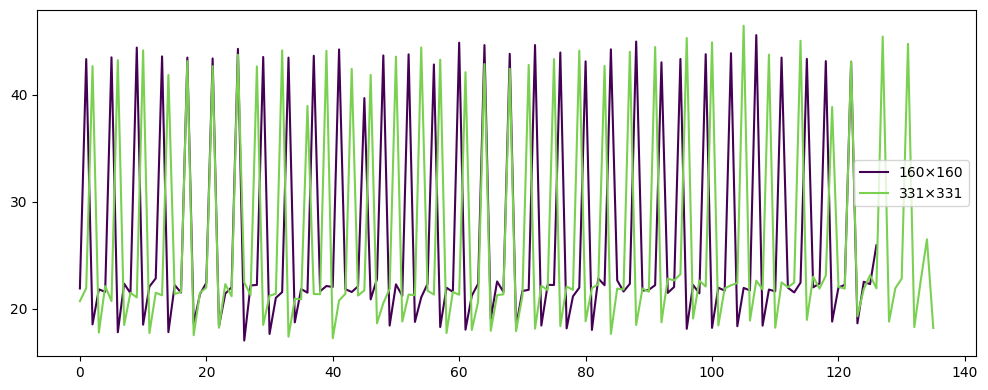

In [3]:
pos_160 = file["position"]["custom_net)160)1"][:]
segment_160 = trace_160[pos_160[1,0]:pos_160[1,1]]
pos_331 = file["position"]["custom_net)331)1"][:]
segment_331 = trace_331[pos_331[1,0]:pos_331[1,1]]

def plot_two_traces(signal1, signal2, label1='Trace 1', label2='Trace 2'):
    cmap = plt.get_cmap('viridis')
    color1 = cmap(0)  # 比较浅的绿
    color2 = cmap(0.8)  # 比较深的紫

    plt.figure(figsize=(10, 4))
    plt.plot(signal1, label=label1, color=color1, alpha=1)
    plt.plot(signal2, label=label2, color=color2, alpha=1)
    plt.yticks([20, 30, 40])
    plt.legend()
    plt.tight_layout()
    plt.savefig("./plot/part_trace_compare.eps", format="eps")

    plt.show()


plot_two_traces(segment_160, segment_331, label1="160×160", label2="331×331")

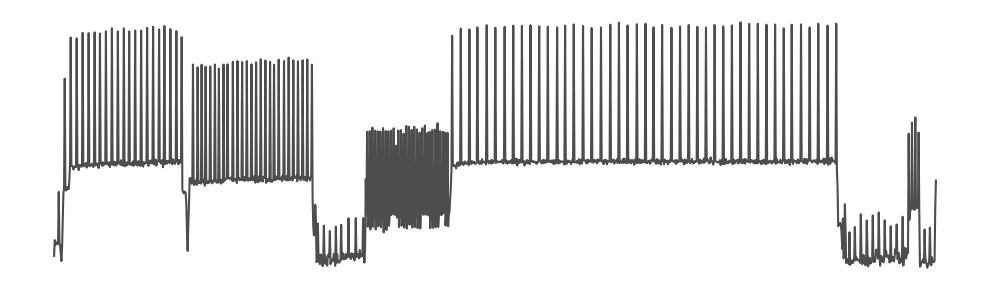

In [21]:
import matplotlib.pyplot as plt
import numpy as np

def plot_single_gray_trace(signal, file_name, color=None ):
    plt.figure(figsize=(10, 3))
    plt.plot(signal, color=color if color != None else [0.3,0.3,0.3], linewidth=1.5)
    plt.axis('off')  # 不显示坐标轴
    plt.tight_layout()
    plt.savefig(file_name, format="pdf")
    plt.show()

plot_single_gray_trace(trace_160, "./plot/gray_trace.pdf")

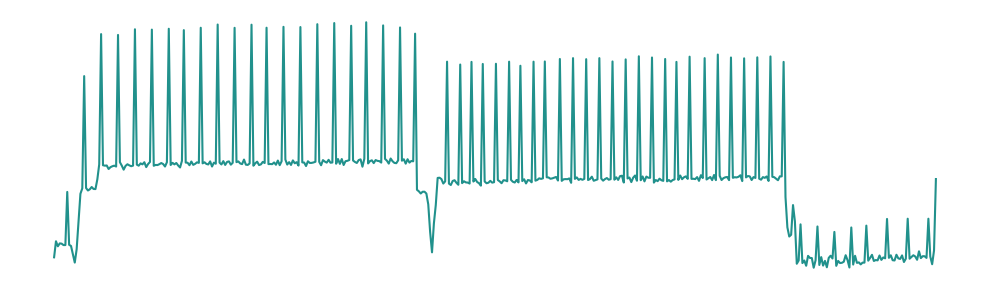

In [22]:
a = np.array(file["data"]["custom_net)160)1"][:,1])
b = np.array(file["data"]["custom_net)160)1"][:,3])
trace_conv2d = a[b==0]
plot_single_gray_trace(trace_conv2d, "./plot/trace_conv2d.pdf", color = "#21918c")